## 0. Imports, Setup

We created specific utils file for each part of the project.

In [31]:
import sys
import os
import pickle
import pandas as pd

from sklearn.model_selection import train_test_split

SRC_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", "src"))
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

from text_mining_utils import (
    LABEL_MAP,
    RANDOM_STATE,
    make_split,
    preprocess_pipeline,
    evaluate_model,
    plot_model_confusion_matrix,
    detect_transformer_device,
    run_transformer_encoder_experiment,
    # EDA helpers
    plot_class_distribution, plot_tweet_length_distribution,
    plot_wordclouds, plot_top_tokens, show_preprocessing_examples,
)

#agentic
import json
import re
import warnings
from functools import lru_cache

import numpy as np
from transformers import pipeline

from langchain_core.tools import tool
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_classic.agents import AgentExecutor, Tool, create_tool_calling_agent
from langchain_classic.memory import ConversationBufferMemory
from langchain_openai import AzureChatOpenAI

warnings.filterwarnings("ignore")

DATA_DIR  = os.path.abspath(os.path.join(os.getcwd(), "..", "data"))
TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
TEST_CSV  = os.path.join(DATA_DIR, "test.csv")

TM_SPLIT_RAW_PATH         = os.path.join(DATA_DIR, "tm_split_raw.pkl")
TM_SPLIT_CLASSICAL_PATH   = os.path.join(DATA_DIR, "tm_split_classical.pkl")
TM_SPLIT_TRANSFORMER_PATH = os.path.join(DATA_DIR, "tm_split_transformer.pkl")
EMBEDDING_CACHE_DIR       = os.path.join(DATA_DIR, "transformer_cache")
os.makedirs(EMBEDDING_CACHE_DIR, exist_ok=True)

# Load the datasets
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

## 1. Data Exploration


In [2]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9543 entries, 0 to 9542
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    9543 non-null   object
 1   label   9543 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 149.2+ KB


In [3]:
(train_df["label"].value_counts(normalize=True).sort_index() * 100).round(2)

label
0    15.11
1    20.15
2    64.74
Name: proportion, dtype: float64

In [4]:
train_df.head()

,text,label
0,$BYND - JPMorgan reels in expectations on Beyo...,0
1,$CCL $RCL - Nomura points to bookings weakness...,0
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0
3,$ESS: BTIG Research cuts to Neutral https://t....,0
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0


### 1.2 Class Distribution

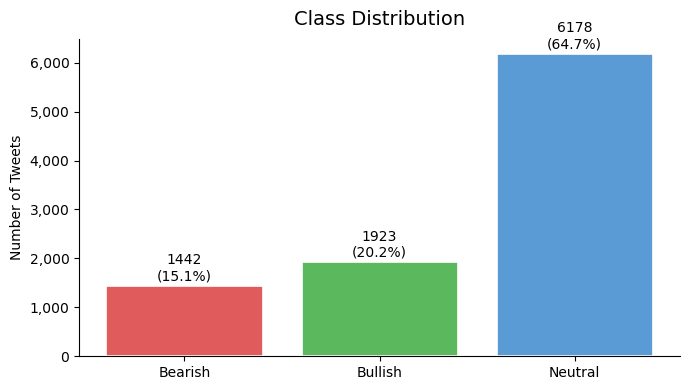

In [5]:
plot_class_distribution(train_df, label_col="label")

The majority of the dataset has as label "Neutral", showing great class imbalacement.

### 1.3 Tweet Length Distribution

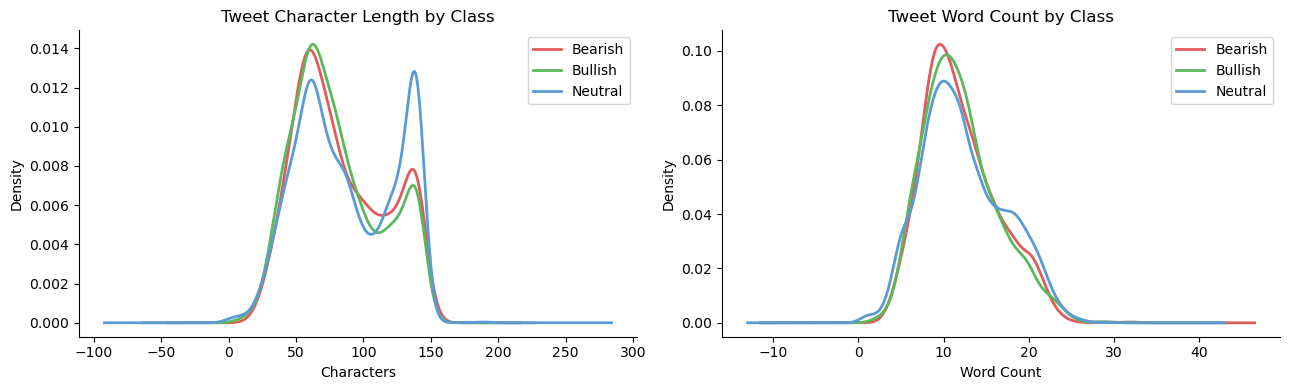

In [6]:
plot_tweet_length_distribution(train_df, text_col="text", label_col="label")

In [7]:
# Summary stats per class
train_df["char_len"]  = train_df["text"].str.len()
train_df["word_count"] = train_df["text"].str.split().str.len()

train_df.groupby("label")[["char_len", "word_count"]].describe().round(1)

char_len                                             word_count        \
         count  mean   std   min   25%   50%    75%    max      count  mean   
label                                                                         
0       1442.0  83.4  33.0  20.0  57.2  75.5  111.0  151.0     1442.0  12.0   
1       1923.0  80.4  32.4   9.0  57.0  74.0  103.0  154.0     1923.0  11.9   
2       6178.0  88.1  36.2   2.0  59.0  82.0  125.0  190.0     6178.0  12.3   

                                        
       std  min  25%   50%   75%   max  
label                                   
0      4.3  3.0  9.0  11.0  15.0  32.0  
1      4.3  2.0  9.0  11.0  14.0  29.0  
2      4.8  1.0  9.0  12.0  16.0  29.0

We conclude that does not exist a difference between the tweet sizes and the label.

### 1.4 Word Clouds per Class

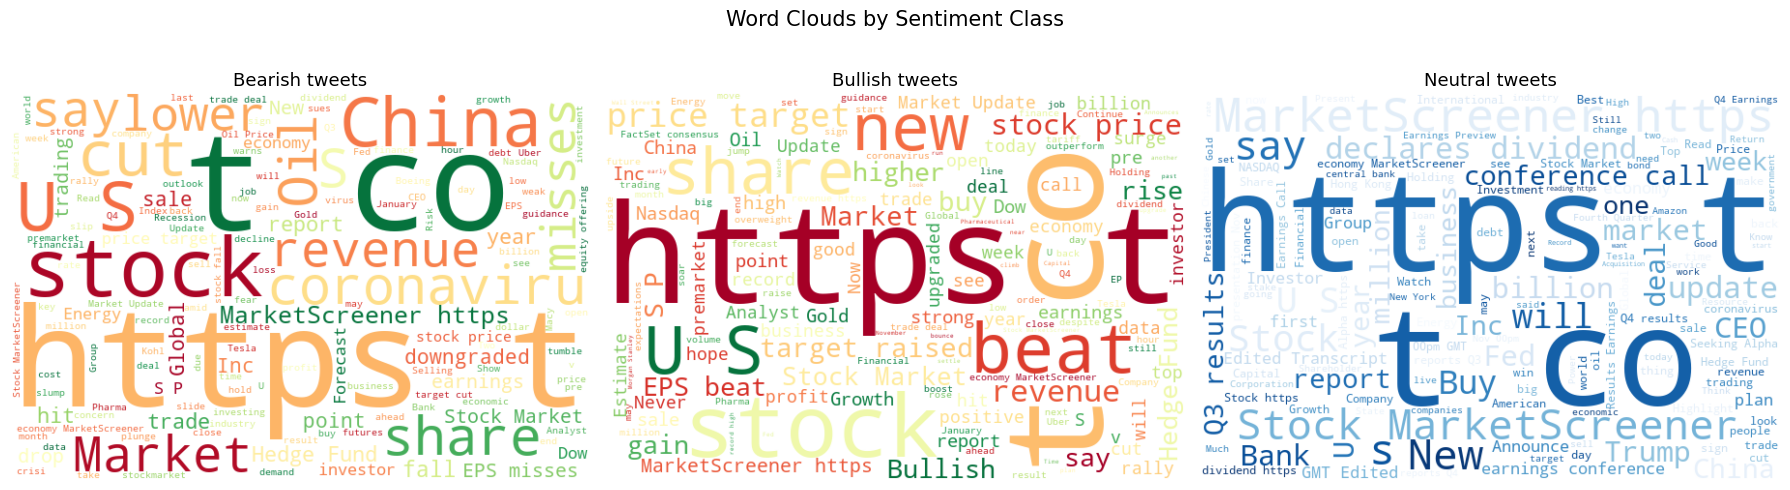

In [8]:
plot_wordclouds(train_df, text_col="text", label_col="label")

From the word clouds before preprocessing, frequent tokens are still dominated by noisy market syntax (tickers, short boilerplate fragments, and repeated symbols). This motivates the use of stronger normalization before feature extraction.

### 1.5 Top Tokens per Class (before preprocessing)

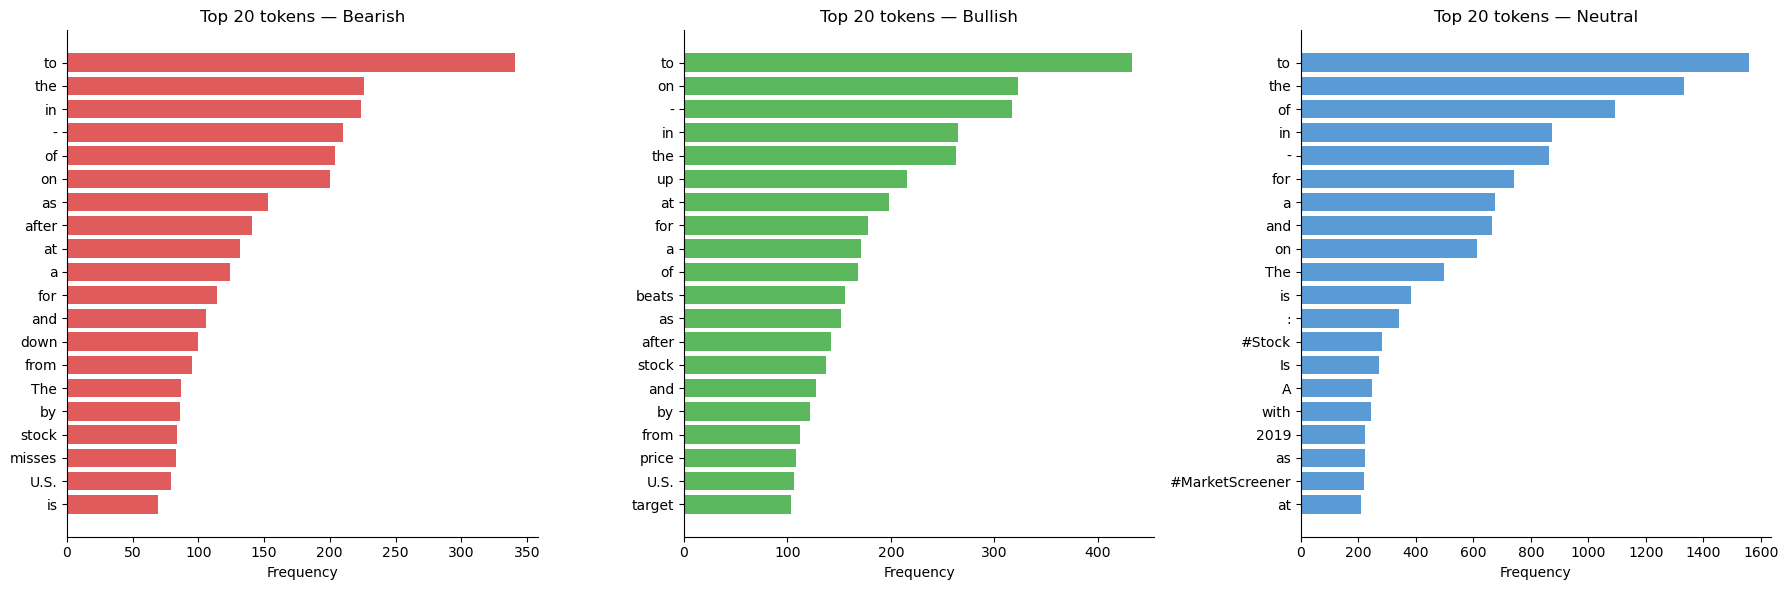

In [9]:
plot_top_tokens(train_df, text_col="text", label_col="label", n=20)

## 2. Data Preprocessing

The preprocessing logic is now mode-based in `preprocess_pipeline` (from `text_mining_utils.py`), with two clear routes depending on the modeling approach.

### Available modes
1. `mode="classical"` (for BoW / TF-IDF / Word2Vec style pipelines)
   - Regex noise removal
   - Tokenization (TweetTokenizer)
   - Stop word removal
   - POS-aware lemmatization

2. `mode="transformer"` (for Transformer Encoder models)
   - Lightweight normalization with placeholder tokens
   - Examples: `[URL]`, `[USER]`, `[CASHTAG]`, `[HASHTAG]`, `[RT]`
   - Keeps richer context for model tokenizers, instead of aggressive token filtering

This keeps one unified API while matching best practices for classical NLP vs transformer workflows.

### 2.1 Before / After Examples - Classical Mode

In [10]:
examples_df = show_preprocessing_examples(
    train_df, text_col="text", n=10, pipeline_fn=preprocess_pipeline
)
examples_df

,original,preprocessed
0,Nokia stock price target raised to $6.00 from ...,nokia stock price target raise mkm partner
1,Russia backs OPEC+ oil output cuts,russia back opec oil output cut
2,Many workers don't have access to retirement s...,many worker access retirement saving program e...
3,About 200 Google employees demonstrated outsid...,google employee demonstrate outside company sa...
4,IDG Energy Investment : VOLUNTARY ANNOUNCEMENT...,idg energy investment voluntary announcement i...
5,Vans parent VF Corp. says 60% of China stores ...,van parent vf corp say china store close coron...
6,AU Optronics reports Q4 results,au optronics report q result
7,$KZR Kezar Life Sciences Highlights Therapeuti...,kezar life science highlight therapeutic poten...
8,U.S. Oil Inventories Rise More Than Expected #...,u oil inventory rise expect wti stock marketsc...
9,A Big Step Forward For the Treatment of ALS,big step forward treatment al


### 2.2 Before / After Examples - Transformer Mode

In [11]:
examples_df = show_preprocessing_examples(
    train_df, text_col="text", n=10, pipeline_fn=preprocess_pipeline, mode = "transformer"
)
examples_df

,original,preprocessed
0,Nokia stock price target raised to $6.00 from ...,Nokia stock price target raised to $6.00 from ...
1,Russia backs OPEC+ oil output cuts,Russia backs OPEC+ oil output cuts
2,Many workers don't have access to retirement s...,Many workers don't have access to retirement s...
3,About 200 Google employees demonstrated outsid...,About 200 Google employees demonstrated outsid...
4,IDG Energy Investment : VOLUNTARY ANNOUNCEMENT...,IDG Energy Investment : VOLUNTARY ANNOUNCEMENT...
5,Vans parent VF Corp. says 60% of China stores ...,Vans parent VF Corp. says 60% of China stores ...
6,AU Optronics reports Q4 results,AU Optronics reports Q4 results
7,$KZR Kezar Life Sciences Highlights Therapeuti...,[CASHTAG] Kezar Life Sciences Highlights Thera...
8,U.S. Oil Inventories Rise More Than Expected #...,U.S. Oil Inventories Rise More Than Expected [...
9,A Big Step Forward For the Treatment of ALS,A Big Step Forward For the Treatment of ALS


### 2.3 Top Tokens After Preprocessing

Compare the top tokens before and after — confirms noise removal and stop word filtering worked.

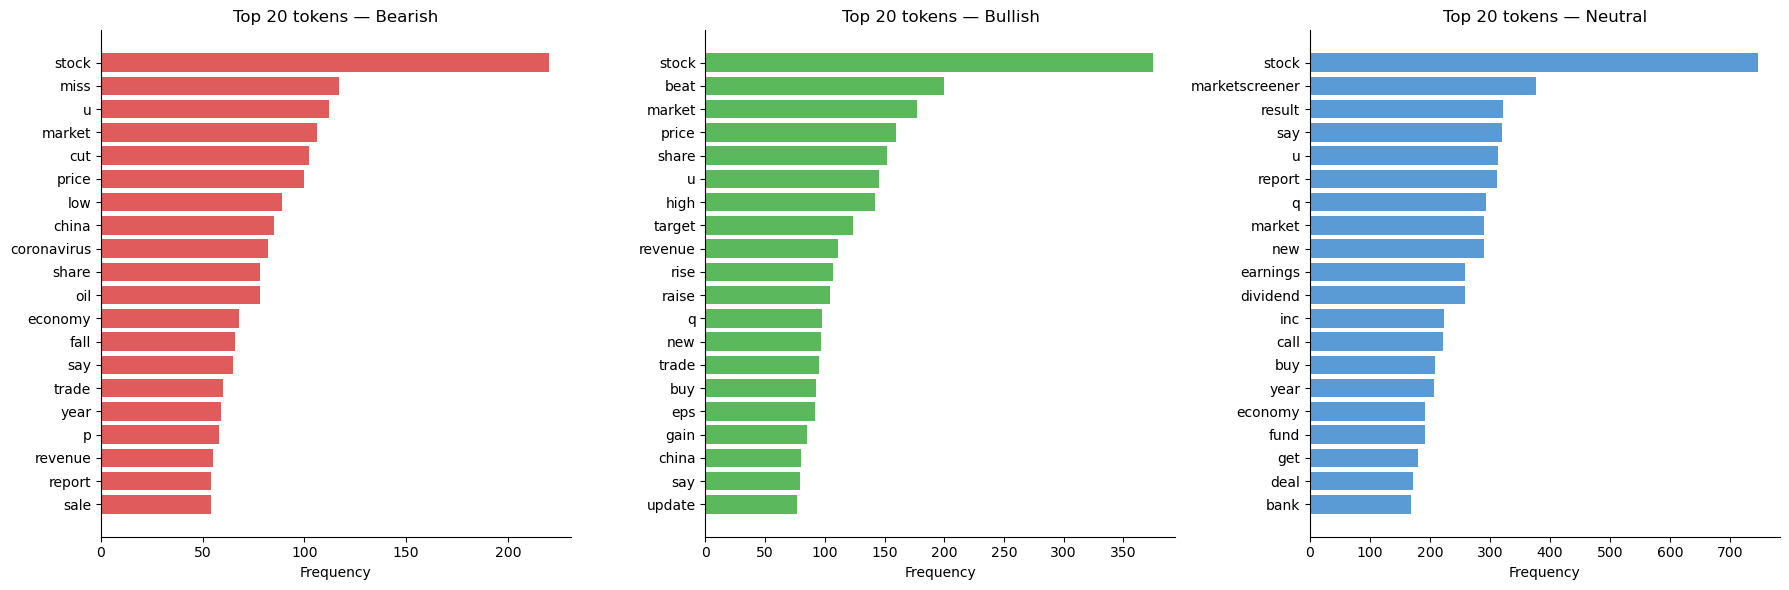

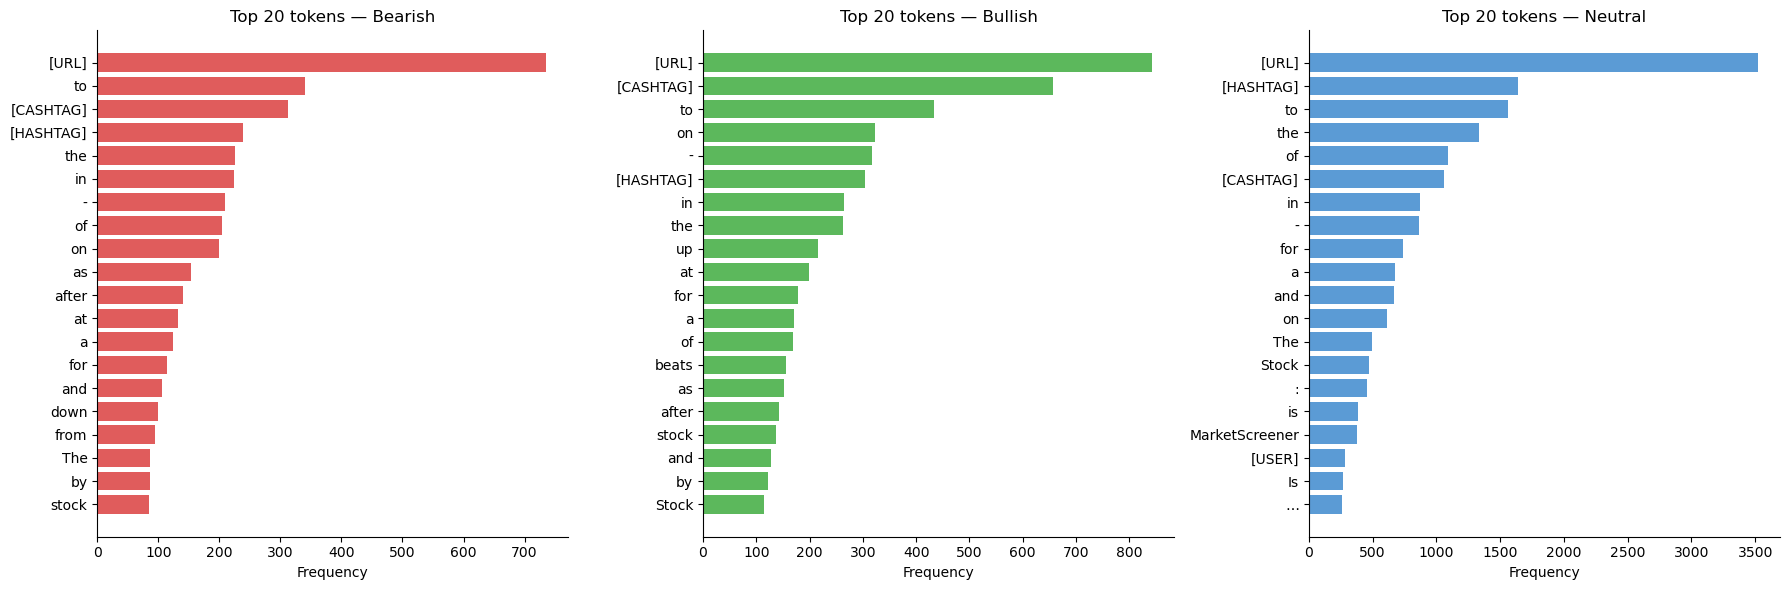

In [12]:
# Build a temporary df with preprocessed text for the full train set (for visualization only)
train_df["text_classical"] = preprocess_pipeline(train_df["text"])
train_df["text_transformer"] = preprocess_pipeline(train_df["text"], mode="transformer")

plot_top_tokens(train_df, text_col="text_classical", label_col="label", n=20)
plot_top_tokens(train_df, text_col="text_transformer", label_col="label", n=20)

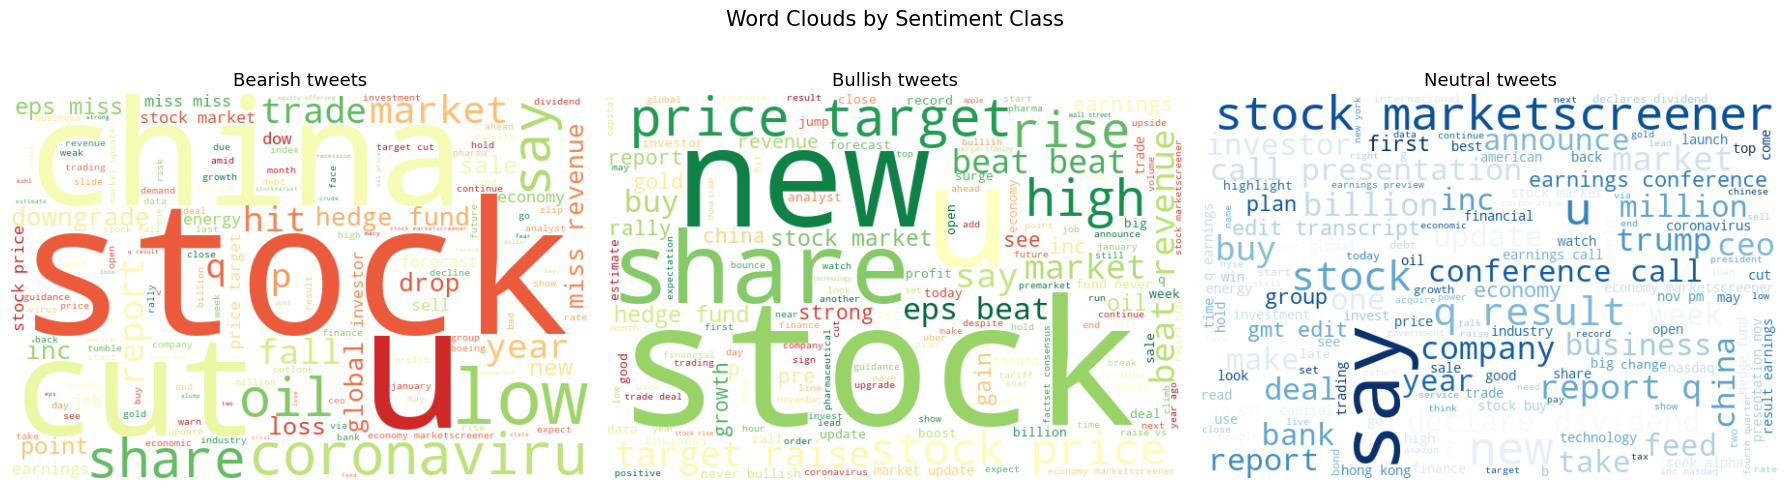

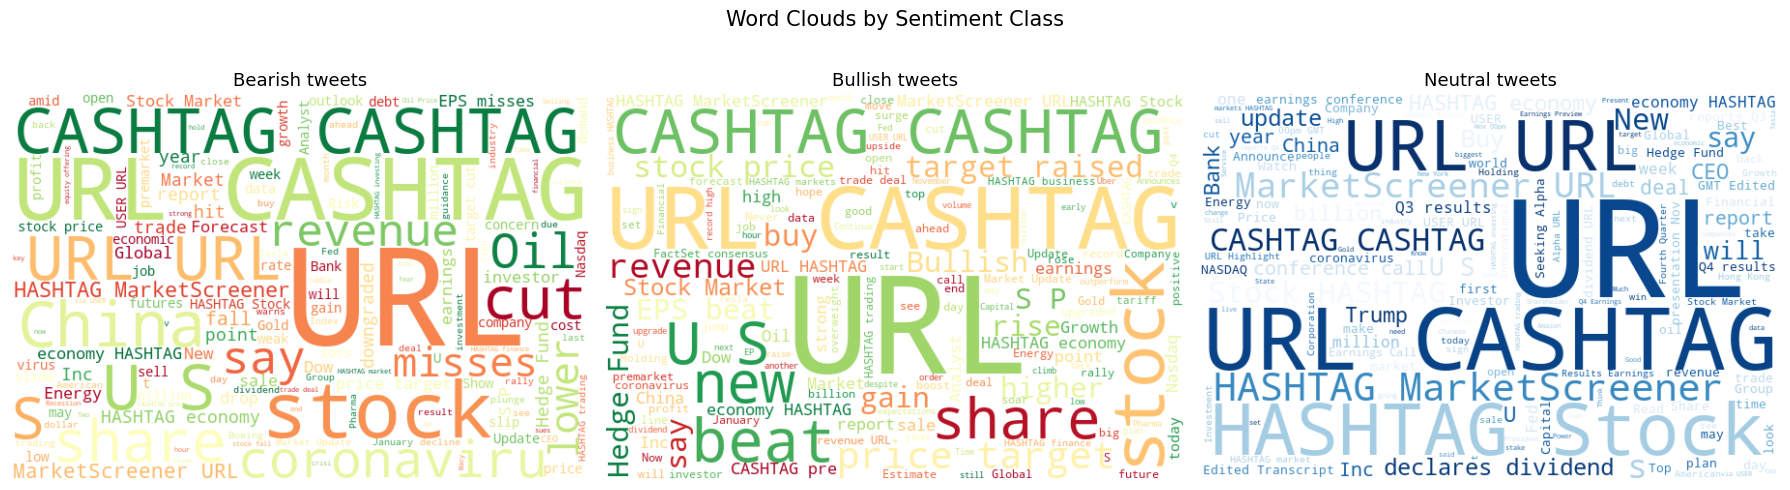

In [13]:
# Word clouds after preprocessing
plot_wordclouds(train_df, text_col="text_classical", label_col="label")
plot_wordclouds(train_df, text_col="text_transformer", label_col="label")

Preprocessing results are consistent with the intended behavior of both routes:
- Classical mode highlights cleaner semantic tokens useful for traditional vectorizers.
- Transformer mode preserves contextual cues through placeholder tokens such as `[URL]`, `[USER]`, and `[CASHTAG]`, which can help downstream transformer tokenizers retain structure.

# 3. Data Split

### 3.1 Shared Train / Validation Split

We keep one stratified split and derive two text views from it:
- `classical`: lemmatized text for BoW / TF-IDF / Word2Vec experiments.
- `transformer`: lightweight normalization for encoder-based models.

### 3.2 Build and Save the Three Text Views

In [14]:
raw_split = make_split(
    train_df,
    text_col="text",
    label_col="label",
    test_size=0.2,
    save_path=TM_SPLIT_RAW_PATH,
)

X_train_raw = raw_split["X_train"]
X_val_raw   = raw_split["X_val"]
y_train     = raw_split["y_train"]
y_val       = raw_split["y_val"]

X_train_classical = preprocess_pipeline(X_train_raw, mode="classical")
X_val_classical   = preprocess_pipeline(X_val_raw, mode="classical")

X_train_transformer = preprocess_pipeline(X_train_raw, mode="transformer")
X_val_transformer   = preprocess_pipeline(X_val_raw, mode="transformer")

with open(TM_SPLIT_CLASSICAL_PATH, "wb") as f:
    pickle.dump(
        {
            "X_train": X_train_classical,
            "X_val": X_val_classical,
            "y_train": y_train,
            "y_val": y_val,
        },
        f,
    )

with open(TM_SPLIT_TRANSFORMER_PATH, "wb") as f:
    pickle.dump(
        {
            "X_train": X_train_transformer,
            "X_val": X_val_transformer,
            "y_train": y_train,
            "y_val": y_val,
        },
        f,
    )

print(f"Saved raw split         -> {TM_SPLIT_RAW_PATH}")
print(f"Saved classical split   -> {TM_SPLIT_CLASSICAL_PATH}")
print(f"Saved transformer split -> {TM_SPLIT_TRANSFORMER_PATH}")

Train size      : 7634 samples
Validation size : 1909 samples
Split saved to  : c:\Users\joaop\master\text mining\text_mining_project\data\tm_split_raw.pkl


Saved raw split         -> c:\Users\joaop\master\text mining\text_mining_project\data\tm_split_raw.pkl
Saved classical split   -> c:\Users\joaop\master\text mining\text_mining_project\data\tm_split_classical.pkl
Saved transformer split -> c:\Users\joaop\master\text mining\text_mining_project\data\tm_split_transformer.pkl


In [15]:
pd.DataFrame(
    {
        "raw": X_train_raw.head(3).to_list(),
        "classical": X_train_classical.head(3).to_list(),
        "transformer": X_train_transformer.head(3).to_list(),
        "label": y_train.head(3).to_list(),
    }
)

,raw,classical,transformer,label
0,"Container Service Returning To Portland, Oregon",container service return portland oregon,"Container Service Returning To Portland, Oregon",2
1,Japan Tobacco reports FY results,japan tobacco report fy result,Japan Tobacco reports FY results,2
2,$OPK squeeze into the close !!!! $INPX strong...,squeeze close strong close,[CASHTAG] squeeze into the close !!!! [CASHTAG...,1


# 4. Feature Engineering

### 4.1 Transformer Encoder Features

Following the same idea used in Lab 4, we convert each tweet into a dense vector with a Hugging Face encoder and then feed those vectors into a simple classifier.


In [16]:
TRANSFORMER_MODELS = {
    "DistilBERT Encoder + Logistic Regression": "distilbert-base-uncased",
    "Twitter RoBERTa Encoder + Logistic Regression": "cardiffnlp/twitter-roberta-base",
}

BATCH_SIZE = 16
MAX_LENGTH = 96
TRAIN_LIMIT = None 
VAL_LIMIT = None    

device, device_name = detect_transformer_device()

X_train_tf_exp = X_train_transformer.copy()
y_train_tf_exp = y_train.copy()
X_val_tf_exp = X_val_transformer.copy()
y_val_tf_exp = y_val.copy()

if TRAIN_LIMIT is not None and len(X_train_tf_exp) > TRAIN_LIMIT:
    X_train_tf_exp, _, y_train_tf_exp, _ = train_test_split(
        X_train_tf_exp,
        y_train_tf_exp,
        train_size=TRAIN_LIMIT,
        stratify=y_train_tf_exp,
        random_state=RANDOM_STATE,
    )

if VAL_LIMIT is not None and len(X_val_tf_exp) > VAL_LIMIT:
    X_val_tf_exp, _, y_val_tf_exp, _ = train_test_split(
        X_val_tf_exp,
        y_val_tf_exp,
        train_size=VAL_LIMIT,
        stratify=y_val_tf_exp,
        random_state=RANDOM_STATE,
    )

print(f"Using device: {device_name}")
print(f"Training tweets: {len(X_train_tf_exp):,}")
print(f"Validation tweets: {len(X_val_tf_exp):,}")

Using device: cpu
Training tweets: 7,634
Validation tweets: 1,909


# 5. Classification Models

For the Transformer Encoder part of the assignment, we test two encoder variations using exactly the same downstream classifier:
- DistilBERT encoder + Logistic Regression
- Twitter RoBERTa encoder + Logistic Regression

In [17]:
transformer_runs = {}
transformer_metrics = []

for experiment_name, checkpoint in TRANSFORMER_MODELS.items():
    result = run_transformer_encoder_experiment(
        experiment_name=experiment_name,
        model_checkpoint=checkpoint,
        X_train_text=X_train_tf_exp,
        y_train_labels=y_train_tf_exp,
        X_val_text=X_val_tf_exp,
        y_val_labels=y_val_tf_exp,
        cache_dir=EMBEDDING_CACHE_DIR,
        batch_size=BATCH_SIZE,
        max_length=MAX_LENGTH,
        device=device,
    )
    transformer_runs[experiment_name] = result
    transformer_metrics.append(result["metrics"])

transformer_results_df = (
    pd.DataFrame(transformer_metrics)
    .sort_values("f1_macro", ascending=False)
    .reset_index(drop=True)
)
transformer_results_df

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBERT Encoder + Logistic Regression - train:   0%|          | 0/478 [00:00<?, ?it/s]

Saved train embeddings to c:\Users\joaop\master\text mining\text_mining_project\data\transformer_cache\train_distilbert_base_uncased_n7634_l96.pkl


DistilBERT Encoder + Logistic Regression - validation:   0%|          | 0/120 [00:00<?, ?it/s]

...

Twitter RoBERTa Encoder + Logistic Regression - train:   0%|          | 0/478 [00:00<?, ?it/s]

Saved train embeddings to c:\Users\joaop\master\text mining\text_mining_project\data\transformer_cache\train_cardiffnlp__twitter_roberta_base_n7634_l96.pkl


Twitter RoBERTa Encoder + Logistic Regression - validation:   0%|          | 0/120 [00:00<?, ?it/s]

Saved validation embeddings to c:\Users\joaop\master\text mining\text_mining_project\data\transformer_cache\val_cardiffnlp__twitter_roberta_base_n1909_l96.pkl

Twitter RoBERTa Encoder + Logistic Regression
              precision    recall  f1-score   support

     Bearish       0.55      0.77      0.64       288
     Bullish       0.67      0.76      0.72       385
     Neutral       0.92      0.80      0.85      1236

    accuracy                           0.79      1909
   macro avg       0.71      0.78      0.74      1909
weighted avg       0.81      0.79      0.79      1909



,model,accuracy,precision,recall,f1_macro
0,Twitter RoBERTa Encoder + Logistic Regression,0.7852,0.7143,0.7757,0.7366
1,DistilBERT Encoder + Logistic Regression,0.7486,0.6716,0.7316,0.6926


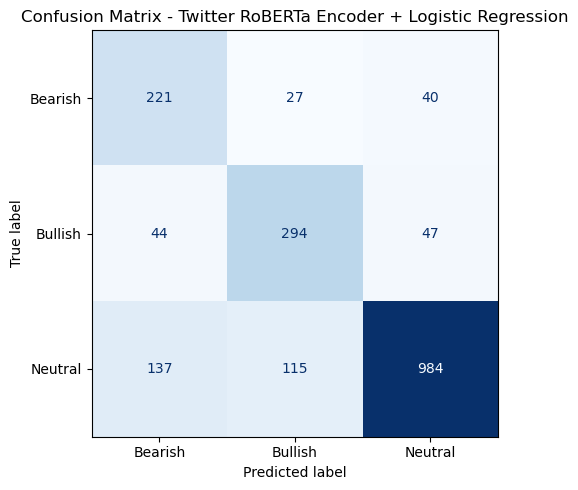

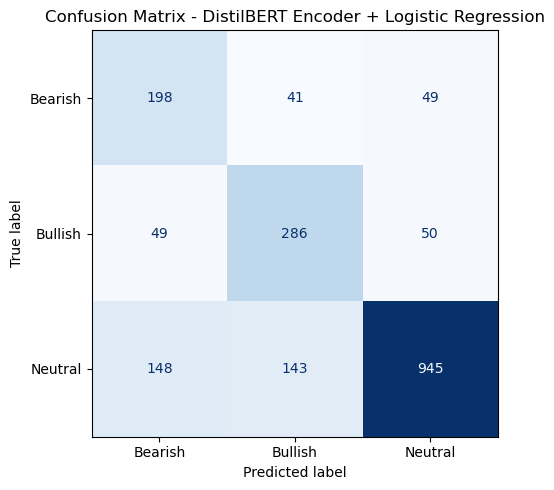

In [18]:
for experiment_name in transformer_results_df["model"]:
    plot_model_confusion_matrix(
        y_val_tf_exp,
        transformer_runs[experiment_name]["predictions"],
        model_name=experiment_name,
    )

## 6. Agentic AI 

We now turn the tweet classifiers into **tools** and give an LLM the job of **routing, comparing, and justifying** predictions.


In [ ]:
MODEL_REGISTRY = {
    name: {
        "checkpoint": run["checkpoint"],
        "classifier": run["classifier"],
        "metrics": run["metrics"],
    }
    for name, run in transformer_runs.items()
}
MODEL_NAME_LOOKUP = {name.lower(): name for name in MODEL_REGISTRY}


@lru_cache(maxsize=None)
def get_feature_extractor(model_checkpoint: str):
    return pipeline(
        "feature-extraction",
        model=model_checkpoint,
        tokenizer=model_checkpoint,
        batch_size=1,
        device=device,
    )


def embed_tweet_for_model(text: str, model_checkpoint: str) -> tuple[np.ndarray, str]:
    processed = preprocess_pipeline(pd.Series([text]), mode="transformer").iloc[0]
    outputs = get_feature_extractor(model_checkpoint)(
        [processed],
        truncation=True,
        padding=True,
        max_length=MAX_LENGTH,
    )
    arr = np.asarray(outputs[0], dtype=np.float32)
    if arr.ndim == 3:
        arr = arr[0]
    return arr[0].reshape(1, -1), processed


def run_model_prediction(experiment_name: str, text: str) -> dict:
    config = MODEL_REGISTRY[experiment_name]
    classifier = config["classifier"]
    embedding, processed = embed_tweet_for_model(text, config["checkpoint"])

    pred_id = int(classifier.predict(embedding)[0])
    probs = classifier.predict_proba(embedding)[0]
    probabilities = {
        LABEL_MAP[int(label_id)]: round(float(prob), 4)
        for label_id, prob in zip(classifier.classes_, probs)
    }
    ranking = sorted(probabilities.items(), key=lambda item: item[1], reverse=True)

    return {
        "model": experiment_name,
        "checkpoint": config["checkpoint"],
        "preprocessed_text": processed,
        "predicted_label": LABEL_MAP[pred_id],
        "confidence": round(ranking[0][1], 4),
        "probabilities": probabilities,
    }


def format_prediction_result(result: dict) -> str:
    prob_str = ", ".join(
        f"{label}={prob:.4f}" for label, prob in result["probabilities"].items()
    )
    return (
        f"model: {result['model']}\n"
        f"predicted_label: {result['predicted_label']}\n"
        f"confidence: {result['confidence']:.4f}\n"
        f"probabilities: {prob_str}\n"
        f"preprocessed_text: {result['preprocessed_text']}"
    )


In [21]:
#  Classification tools

@tool
def inspect_tweet_profile(text: str) -> str:
    '''Inspect a tweet and summarize the signals that matter for model routing.
    Use before choosing which classifier to trust.
    Args:
        text: Raw tweet text.
    '''
    tweet = str(text)
    words = tweet.split()
    url_count = len(re.findall(r"http\S+|www\.\S+", tweet))
    mention_count = len(re.findall(r"@\w+", tweet))
    hashtag_count = len(re.findall(r"#\w+", tweet))
    cashtag_count = len(re.findall(r"\$[A-Za-z]+", tweet))
    uppercase_tokens = sum(1 for token in words if token.isupper() and len(token) > 1)
    noise_score = url_count + mention_count + hashtag_count + cashtag_count + uppercase_tokens

    if noise_score >= 2 or len(words) <= 6:
        suggested_strategy = "compare_both_models"
    elif hashtag_count + cashtag_count + mention_count + url_count >= 1:
        suggested_strategy = "prefer_twitter_roberta"
    else:
        suggested_strategy = "prefer_distilbert"

    summary = {
        "char_length": len(tweet),
        "word_count": len(words),
        "urls": url_count,
        "mentions": mention_count,
        "hashtags": hashtag_count,
        "cashtags": cashtag_count,
        "uppercase_tokens": uppercase_tokens,
        "suggested_strategy": suggested_strategy,
    }
    return json.dumps(summary, indent=2)


@tool
def get_validation_metrics(model_name: str = "all") -> str:
    '''Return validation metrics for one classifier or for all classifiers.
    Use when you need evidence to recommend or compare models.
    Args:
        model_name: Exact model name, or "all" to list every model.
    '''
    query = str(model_name).strip()
    if query.lower() == "all":
        rows = []
        ranked_models = sorted(
            MODEL_REGISTRY.values(),
            key=lambda item: item["metrics"]["f1_macro"],
            reverse=True,
        )
        for item in ranked_models:
            m = item["metrics"]
            rows.append(
                f"{m['model']} | accuracy={m['accuracy']:.4f} | precision={m['precision']:.4f} | "
                f"recall={m['recall']:.4f} | f1_macro={m['f1_macro']:.4f}"
            )
        return "\n".join(rows)

    matched = MODEL_NAME_LOOKUP.get(query.lower())
    if matched is None:
        available = ", ".join(MODEL_REGISTRY)
        return f"Unknown model: {model_name}. Available models: {available}"

    m = MODEL_REGISTRY[matched]["metrics"]
    return (
        f"{m['model']} | accuracy={m['accuracy']:.4f} | precision={m['precision']:.4f} | "
        f"recall={m['recall']:.4f} | f1_macro={m['f1_macro']:.4f}"
    )


@tool
def classify_with_distilbert(text: str) -> str:
    '''Classify a tweet with the DistilBERT encoder + Logistic Regression pipeline.
    Use when the tweet is relatively clean or when you want a first baseline decision.
    Args:
        text: Raw tweet text.
    '''
    return format_prediction_result(
        run_model_prediction("DistilBERT Encoder + Logistic Regression", text)
    )


@tool
def classify_with_twitter_roberta(text: str) -> str:
    '''Classify a tweet with the Twitter RoBERTa encoder + Logistic Regression pipeline.
    Use when the tweet contains social-media markers such as cashtags, hashtags, mentions, or URLs.
    Args:
        text: Raw tweet text.
    '''
    return format_prediction_result(
        run_model_prediction("Twitter RoBERTa Encoder + Logistic Regression", text)
    )


@tool
def compare_classifier_outputs(text: str) -> str:
    '''Run both classifiers on the same tweet and compare their outputs.
    Use when the routing decision is uncertain or when the user asks for a model comparison.
    Args:
        text: Raw tweet text.
    '''
    distil = run_model_prediction("DistilBERT Encoder + Logistic Regression", text)
    roberta = run_model_prediction("Twitter RoBERTa Encoder + Logistic Regression", text)

    comparison = {
        "agreement": distil["predicted_label"] == roberta["predicted_label"],
        "distilbert": {
            "label": distil["predicted_label"],
            "confidence": distil["confidence"],
        },
        "twitter_roberta": {
            "label": roberta["predicted_label"],
            "confidence": roberta["confidence"],
        },
        "recommended_output": (
            roberta["predicted_label"]
            if roberta["confidence"] >= distil["confidence"]
            else distil["predicted_label"]
        ),
    }
    return json.dumps(comparison, indent=2)


### 6.2 Building the conversational agent

The structure below is modular: define tools, create specialized agents, then expose a single conversational interface through an orchestrator.


In [22]:
# Load the Azure OpenAI setup

COURSE_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
AZURE_KEY_PATH = os.path.join(COURSE_ROOT, "Lab 5", "Azure Open AI Key.txt")

with open(AZURE_KEY_PATH, "r", encoding="utf-8") as f:
    azure_key = f.read().strip()

os.environ["AZURE_OPENAI_KEY"] = azure_key
os.environ["AZURE_OPENAI_ENDPOINT"] = "https://novaimsplayground.openai.azure.com/"

llm = AzureChatOpenAI(
    temperature=0,
    model="ChatGPT",
    azure_endpoint=os.environ["AZURE_OPENAI_ENDPOINT"],
    openai_api_type="azure",
    api_key=os.environ["AZURE_OPENAI_KEY"],
    api_version="2024-02-15-preview",
)

print("LLM ready:", llm.model_name)


LLM ready: ChatGPT


In [23]:
#  Agent 1: Routing Agent - decides which model strategy fits the tweet best
routing_tools = [inspect_tweet_profile, get_validation_metrics]
routing_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are a tweet-routing specialist. Decide which classifier strategy is more appropriate "
        "for the user's request. Always inspect the tweet profile first when the task is tweet classification. "
        "Use validation metrics when you need evidence. Output a short recommendation choosing exactly one of: "
        "prefer_distilbert, prefer_twitter_roberta, or compare_both_models.",
    ),
    ("human", "{input}"),
    MessagesPlaceholder("agent_scratchpad"),
])
routing_agent = create_tool_calling_agent(llm, routing_tools, routing_prompt)
routing_executor = AgentExecutor(
    agent=routing_agent,
    tools=routing_tools,
    verbose=False,
    return_intermediate_steps=True,
)

#  Agent 2: Classification Agent - runs the selected model or compares both
classification_tools = [
    classify_with_distilbert,
    classify_with_twitter_roberta,
    compare_classifier_outputs,
]
classification_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are a tweet sentiment classification specialist. Read the user's request and any routing advice. "
        "If the advice says compare_both_models or if the tweet looks ambiguous, use compare_classifier_outputs. "
        "Otherwise use the most appropriate single-model classification tool. "
        "Always report the final sentiment label and mention which model output you used.",
    ),
    ("human", "{input}"),
    MessagesPlaceholder("agent_scratchpad"),
])
classification_agent = create_tool_calling_agent(llm, classification_tools, classification_prompt)
classification_executor = AgentExecutor(
    agent=classification_agent,
    tools=classification_tools,
    verbose=False,
    return_intermediate_steps=True,
)

print("Routing tools:", [tool.name for tool in routing_tools])
print("Classification tools:", [tool.name for tool in classification_tools])


Routing tools: ['inspect_tweet_profile', 'get_validation_metrics']
Classification tools: ['classify_with_distilbert', 'classify_with_twitter_roberta', 'compare_classifier_outputs']


In [24]:
# 1. Wrap the specialist executors as agent tools
routing_tool = Tool(
    name="routing_expert",
    func=lambda q: routing_executor.invoke({"input": q})["output"],
    description=(
        "Use this tool first when the user asks to classify a tweet or choose a model. "
        "It inspects tweet structure and recommends one strategy: prefer_distilbert, "
        "prefer_twitter_roberta, or compare_both_models."
    ),
)

classification_tool = Tool(
    name="classification_expert",
    func=lambda q: classification_executor.invoke({"input": q})["output"],
    description=(
        "Use this tool to run the actual tweet classifier or compare both classifiers and return "
        "the grounded final prediction."
    ),
)

# 2. Define the orchestrator
orchestrator_tools = [routing_tool, classification_tool]
orchestrator_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are the project orchestrator for a tweet classification pipeline. "
        "Your job is to coordinate experts, not to guess labels yourself. "
        "For tweet classification tasks, call routing_expert first, then classification_expert. "
        "For evaluation or model recommendation questions, use routing_expert because it has access "
        "to validation metrics. Always ground the final answer in tool outputs.",
    ),
    ("human", "{input}"),
    MessagesPlaceholder("agent_scratchpad"),
])

# 3. Create the orchestrator agent
orchestrator_agent = create_tool_calling_agent(llm, orchestrator_tools, orchestrator_prompt)
orchestrator_executor = AgentExecutor(
    agent=orchestrator_agent,
    tools=orchestrator_tools,
    verbose=True,
    return_intermediate_steps=True,
)

print("Orchestrator tools:", [tool.name for tool in orchestrator_tools])
print("Agent ready.")


def print_trace(result):
    steps = result.get("intermediate_steps", [])
    if not steps:
        print("  (no tool calls in this run)")
        return
    bar = "-" * 62
    print(" ### AGENT THOUGHT TRACE ###")
    print()
    for i, (action, obs) in enumerate(steps):
        inp = action.tool_input
        if isinstance(inp, dict):
            inp_str = ", ".join(f"{k}={repr(v)}" for k, v in inp.items())
        else:
            inp_str = str(inp)
        if len(inp_str) > 120:
            inp_str = inp_str[:120] + "-"
        obs_str = str(obs)
        if len(obs_str) > 400:
            obs_str = obs_str[:400] + "[-truncated]"
        print(f"  Step {i+1}")
        print(bar)
        print(f"  Thought: {action.log.strip()}")
        print(f"  Tool used: {action.tool}  - (Tool's input): ({inp_str})")
        print(f"         -  Result: {obs_str}")
        if i < len(steps) - 1:
            print()


Orchestrator tools: ['routing_expert', 'classification_expert']
Agent ready.


In [25]:
# Run the orchestrator - watch the routing - classification coordination in the output

tweet = "$TSLA is finally breaking out after earnings! Loading more shares now  #bullish"

agentic_result = orchestrator_executor.invoke(
    {
        "input": (
            f"Classify this investor tweet: '{tweet}'. "
            "First choose the most appropriate classifier strategy, then give me the final label, "
            "confidence, and a short justification."
        )
    }
)

print("\n" + "-" * 62)
print("Answer:", agentic_result["output"])
print("-" * 62)




> Entering new AgentExecutor chain...

Invoking: `routing_expert` with `$TSLA is finally breaking out after earnings! Loading more shares now  #bullish`


compare_both_models
Invoking: `classification_expert` with `$TSLA is finally breaking out after earnings! Loading more shares now  #bullish`




Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


The sentiment of the tweet "$TSLA is finally breaking out after earnings! Loading more shares now  #bullish" is Bullish. This classification is based on the output from the Twitter RoBERTa Encoder + Logistic Regression model.The most appropriate classifier strategy for this tweet is to compare both models. The final label for the tweet "$TSLA is finally breaking out after earnings! Loading more shares now  #bullish" is Bullish. The classification is confident and grounded in the output from the Twitter RoBERTa Encoder + Logistic Regression model, which captures the positive sentiment about the stock breaking out and the user's intention to buy more shares.

> Finished chain.

--------------------------------------------------------------
Answer: The most appropriate classifier strategy for this tweet is to compare both models. The final label for the tweet "$TSLA is finally breaking out after earnings! Loading more shares now  #bullish" is Bullish. The classification is confident and g

In [26]:
print_trace(agentic_result)


 ### AGENT THOUGHT TRACE ###

  Step 1
--------------------------------------------------------------
  Thought: Invoking: `routing_expert` with `$TSLA is finally breaking out after earnings! Loading more shares now  #bullish`
  Tool used: routing_expert  - (Tool's input): ($TSLA is finally breaking out after earnings! Loading more shares now  #bullish)
         -  Result: compare_both_models

  Step 2
--------------------------------------------------------------
  Thought: Invoking: `classification_expert` with `$TSLA is finally breaking out after earnings! Loading more shares now  #bullish`
  Tool used: classification_expert  - (Tool's input): ($TSLA is finally breaking out after earnings! Loading more shares now  #bullish)
         -  Result: The sentiment of the tweet "$TSLA is finally breaking out after earnings! Loading more shares now  #bullish" is Bullish. This classification is based on the output from the Twitter RoBERTa Encoder + Logistic Regression model.


### 6.3 Automated evaluation through the same conversational interface

The same agent can answer evaluation prompts as well, using the validation metrics tool instead of hardcoded notebook logic.


In [27]:
evaluation_result = orchestrator_executor.invoke(
    {
        "input": (
            "Compare the available classifiers on the validation set and recommend which one we should deploy "
            "for noisy stock-market tweets with hashtags and cashtags."
        )
    }
)

print("\n" + "-" * 62)
print("Answer:", evaluation_result["output"])
print("-" * 62)




> Entering new AgentExecutor chain...

Invoking: `routing_expert` with `noisy stock-market tweets with hashtags and cashtags`


Based on the tweet profile, I recommend using the prefer_distilbert strategy for classifying noisy stock-market tweets with hashtags and cashtags.For noisy stock-market tweets with hashtags and cashtags, the recommended classifier to deploy is the DistilBERT-based model. If you want, I can proceed to run classification or evaluation using this model.

> Finished chain.

--------------------------------------------------------------
Answer: For noisy stock-market tweets with hashtags and cashtags, the recommended classifier to deploy is the DistilBERT-based model. If you want, I can proceed to run classification or evaluation using this model.
--------------------------------------------------------------


In [28]:
print_trace(evaluation_result)


 ### AGENT THOUGHT TRACE ###

  Step 1
--------------------------------------------------------------
  Thought: Invoking: `routing_expert` with `noisy stock-market tweets with hashtags and cashtags`
  Tool used: routing_expert  - (Tool's input): (noisy stock-market tweets with hashtags and cashtags)
         -  Result: Based on the tweet profile, I recommend using the prefer_distilbert strategy for classifying noisy stock-market tweets with hashtags and cashtags.


### 6.4 Optional memory for follow-up questions

We can also add short-term conversational memory so the user can ask follow-up questions about the previously recommended strategy.


In [29]:
memory = ConversationBufferMemory(memory_key="chat_history", return_messages=True)

orchestrator_prompt_mem = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are the project orchestrator for the tweet classification pipeline. "
        "Use tools to ground all answers and remember previous model recommendations so you can answer follow-up questions.",
    ),
    MessagesPlaceholder("chat_history", optional=True),
    ("human", "{input}"),
    MessagesPlaceholder("agent_scratchpad"),
])

orchestrator_agent_mem = create_tool_calling_agent(llm, orchestrator_tools, orchestrator_prompt_mem)
orchestrator_executor_mem = AgentExecutor(
    agent=orchestrator_agent_mem,
    tools=orchestrator_tools,
    verbose=False,
    memory=memory,
    return_intermediate_steps=True,
)

print("Memory agent ready.")


Memory agent ready.


In [30]:
q1 = "For tweets full of cashtags and hashtags, which model strategy should we prefer- Remember your recommendation."
print(f"User  : {q1}")
ans1 = orchestrator_executor_mem.invoke({"input": q1})
print(f"Agent : {ans1['output']}")
print_trace(ans1)

print()

q2 = "Now classify this tweet using that recommendation: '$NVDA looks unstoppable right now #AI #stocks'"
print(f"User  : {q2}")
ans2 = orchestrator_executor_mem.invoke({"input": q2})
print(f"Agent : {ans2['output']}")
print_trace(ans2)


User  : For tweets full of cashtags and hashtags, which model strategy should we prefer- Remember your recommendation.
Agent : For tweets full of cashtags and hashtags, the recommended strategy is to compare both models (prefer_distilbert and prefer_twitter_roberta) to determine the best classification. I will remember this recommendation for future reference.
 ### AGENT THOUGHT TRACE ###

  Step 1
--------------------------------------------------------------
  Thought: Invoking: `routing_expert` with `$AAPL $TSLA #stocks #investing $GOOG $MSFT #market`
  Tool used: routing_expert  - (Tool's input): ($AAPL $TSLA #stocks #investing $GOOG $MSFT #market)
         -  Result: compare_both_models

User  : Now classify this tweet using that recommendation: '$NVDA looks unstoppable right now #AI #stocks'
Agent : The tweet "$NVDA looks unstoppable right now #AI #stocks" is classified as Bullish based on the Twitter RoBERTa model, following the recommendation to compare both models for tweets w